In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, f1_score)
from sklearn.utils.class_weight import compute_class_weight
 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
 
from imblearn.over_sampling import SMOTE

In [12]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
column_names = [
    'Pregnancy', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'Pedigree', 'Age', 'Outcome'
]
data = pd.read_csv(url, names=column_names)
 
print("=" * 50)
print("Dataset shape:", data.shape)
print("Class distribution:\n", data['Outcome'].value_counts())
print("=" * 50)

Dataset shape: (768, 9)
Class distribution:
 Outcome
0    500
1    268
Name: count, dtype: int64


In [13]:
zero_not_accepted = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
data[zero_not_accepted] = data[zero_not_accepted].replace(0, np.nan)
data.fillna(data.mean(), inplace=True)
 
X = data.drop('Outcome', axis=1).values
y = data['Outcome'].values
 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=1, stratify=y
)
 
print(f"Train size : {X_train.shape[0]} samples")
print(f"Test size  : {X_test.shape[0]} samples")

Train size : 614 samples
Test size  : 154 samples


In [15]:
smote = SMOTE(random_state=1)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
 
print(f"After SMOTE — Train size    : {X_train_res.shape[0]}")
print(f"After SMOTE — Class balance : {dict(zip(*np.unique(y_train_res, return_counts=True)))}")
 

After SMOTE — Train size    : 800
After SMOTE — Class balance : {np.int64(0): np.int64(400), np.int64(1): np.int64(400)}


In [16]:
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_res),
    y=y_train_res
)
class_weight_dict = dict(enumerate(class_weights_array))
print(f"Class weights: {class_weight_dict}")
 
# One-hot encode
y_train_cat = to_categorical(y_train_res, num_classes=2)
y_test_cat  = to_categorical(y_test,      num_classes=2)

Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}


In [17]:
model = Sequential([
    # Input block
    Dense(128, input_dim=8, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
 
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
 
    
    Dense(32, activation='relu'),
    BatchNormalization(),
 
    # Output
    Dense(2, activation='softmax')
])
 
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)
 
model.summary()

C:\Users\ehabr\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,450 (48.63 KB)

 Trainable params: 12,002 (46.88 KB)

 Non-trainable params: 448 (1.75 KB)

In [19]:
early_stop = EarlyStopping(
    monitor='val_loss', patience=20,
    verbose=1, restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    'best_model.keras', monitor='val_accuracy',
    save_best_only=True, mode='max', verbose=0
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=8, min_lr=1e-6, verbose=1
)

In [20]:
history = model.fit(
    X_train_res, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=200,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)
 
print(f"\nTraining stopped at epoch: {len(history.history['loss'])}")

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5950 - loss: 0.8495 - val_accuracy: 0.6623 - val_loss: 0.6481 - learning_rate: 5.0000e-04
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6675 - loss: 0.6738 - val_accuracy: 0.7403 - val_loss: 0.6191 - learning_rate: 5.0000e-04
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7113 - loss: 0.6261 - val_accuracy: 0.7403 - val_loss: 0.5996 - learning_rate: 5.0000e-04
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7500 - loss: 0.5627 - val_accuracy: 0.7727 - val_loss: 0.5753 - learning_rate: 5.0000e-04
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7425 - loss: 0.5287 - val_accuracy: 0.7857 - val_loss: 0.5545 - learning_rate: 5.0000e-04
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7513 - loss: 0.5528 - val_accuracy: 0.7727 - val_loss: 0.5433 - learning_rate: 5.0000e-04
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7588

In [21]:
y_pred_prob = model.predict(X_test)
y_true      = np.argmax(y_test_cat, axis=1)
 
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob[:, 1])
roc_auc = auc(fpr, tpr)
 

f1_scores = []
for t in thresholds:
    preds = (y_pred_prob[:, 1] >= t).astype(int)
    f1_scores.append(f1_score(y_true, preds))
 
optimal_threshold = thresholds[np.argmax(f1_scores)]
print(f"\nDefault  threshold : 0.50")
print(f"Optimal  threshold : {optimal_threshold:.4f}")
 
y_pred_default = (y_pred_prob[:, 1] >= 0.50).astype(int)
y_pred_optimal = (y_pred_prob[:, 1] >= optimal_threshold).astype(int)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

Default  threshold : 0.50
Optimal  threshold : 0.4862


In [22]:
print("\n" + "=" * 50)
print("RESULTS WITH DEFAULT THRESHOLD (0.50)")
print("=" * 50)
print(classification_report(y_true, y_pred_default, target_names=['Healthy', 'Diabetes']))
 
print("\n" + "=" * 50)
print(f"RESULTS WITH OPTIMAL THRESHOLD ({optimal_threshold:.2f})")
print("=" * 50)
print(classification_report(y_true, y_pred_optimal, target_names=['Healthy', 'Diabetes']))
print(f"AUC Score: {roc_auc:.4f}")


RESULTS WITH DEFAULT THRESHOLD (0.50)
              precision    recall  f1-score   support

     Healthy       0.89      0.74      0.81       100
    Diabetes       0.63      0.83      0.72        54

    accuracy                           0.77       154
   macro avg       0.76      0.79      0.76       154
weighted avg       0.80      0.77      0.78       154


RESULTS WITH OPTIMAL THRESHOLD (0.49)
              precision    recall  f1-score   support

     Healthy       0.90      0.73      0.81       100
    Diabetes       0.63      0.85      0.72        54

    accuracy                           0.77       154
   macro avg       0.77      0.79      0.77       154
weighted avg       0.81      0.77      0.78       154

AUC Score: 0.8417


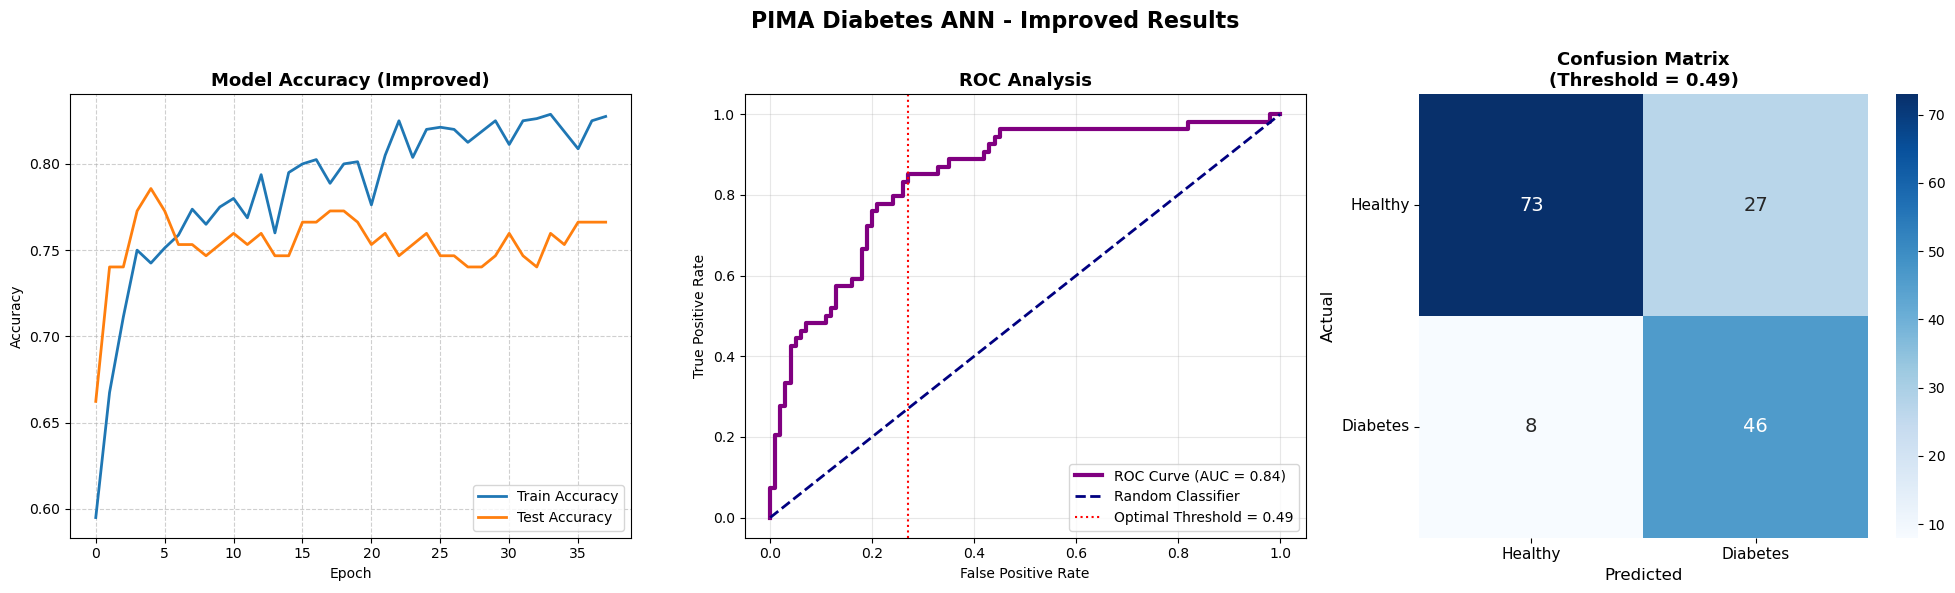


Done! Saved → results.png  |  best_model.keras


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('PIMA Diabetes ANN - Improved Results', fontsize=16, fontweight='bold')
 
# -- Accuracy curve
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Test Accuracy',  linewidth=2)
axes[0].set_title('Model Accuracy (Improved)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend(loc='lower right')
axes[0].grid(True, linestyle='--', alpha=0.6)
 
# -- ROC Curve
axes[1].plot(fpr, tpr, color='purple', lw=3, label=f'ROC Curve (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1].axvline(x=fpr[np.argmax(f1_scores)], color='red', linestyle=':', linewidth=1.5,
                label=f'Optimal Threshold = {optimal_threshold:.2f}')
axes[1].set_title('ROC Analysis', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)
 
# -- Confusion Matrix (optimal threshold)
cm = confusion_matrix(y_true, y_pred_optimal)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2], annot_kws={"size": 14})
axes[2].set_title(f'Confusion Matrix\n(Threshold = {optimal_threshold:.2f})',
                  fontsize=13, fontweight='bold')
axes[2].set_ylabel('Actual',    fontsize=12)
axes[2].set_xlabel('Predicted', fontsize=12)
axes[2].set_xticklabels(['Healthy', 'Diabetes'], fontsize=11)
axes[2].set_yticklabels(['Healthy', 'Diabetes'], fontsize=11, rotation=0)
 
plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
plt.show()
 
print("\nDone! Saved → results.png  |  best_model.keras")
